# NeuralProphet 时序预测——能源价格（含协变量）

使用 NeuralProphet 预测德国未来 24 小时电价，以 **Ampirion 负荷预测** 和 **光伏+风电出力预测** 为已知未来协变量，并与不含协变量的基线对比。

数据：AutoGluon electricity_price（训练集 51936 行，2012-01-09 ~ 2017-12-11，小时级）

预测目标：2017-12-12 00:00 ~ 23:00（24 小时）

In [2]:
import os
# 不使用GPU
os.environ['CUDA_VISIBLE_DEVICES'] = ''
# PyTorch 2.6版本的兼容问题
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from neuralprophet import NeuralProphet, set_log_level
set_log_level('ERROR')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

TIMESERIES_ID     = 'DE'
PREDICTION_LENGTH = 24
SHOW_HISTORY      = 256

energy_context_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet',
    engine='fastparquet'
)
energy_context_df['timestamp'] = pd.to_datetime(energy_context_df['timestamp'])

energy_test_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet',
    engine='fastparquet'
)
energy_test_df['timestamp'] = pd.to_datetime(energy_test_df['timestamp'])

print('训练数据:', energy_context_df.shape, '| 列:', list(energy_context_df.columns))
print(f'时间范围: {energy_context_df["timestamp"].min().date()} ~ {energy_context_df["timestamp"].max().date()}')
print('预测目标日:', energy_test_df['timestamp'].min().date())
energy_context_df.head(3)

训练数据: (51936, 5) | 列: ['id', 'timestamp', 'target', 'Ampirion Load Forecast', 'PV+Wind Forecast']
时间范围: 2012-01-09 ~ 2017-12-11
预测目标日: 2017-12-12


,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.0,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.5,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.0,3107.307617


In [3]:
COV_MAP = {
    'Ampirion Load Forecast': 'ampirion_load',
    'PV+Wind Forecast':       'pv_wind',
}
COV_COLS = list(COV_MAP.values())

df_context = (
    energy_context_df[energy_context_df['id'] == TIMESERIES_ID]
    .rename(columns={'timestamp': 'ds', 'target': 'y', **COV_MAP})
    [['ds', 'y'] + COV_COLS]
    .reset_index(drop=True)
)

df_future_cov = (
    energy_test_df[energy_test_df['id'] == TIMESERIES_ID]
    .rename(columns={'timestamp': 'ds', **COV_MAP})
    [['ds'] + COV_COLS]
    .reset_index(drop=True)
)

print(f'历史上下文: {len(df_context)} 行  ({df_context["ds"].min().date()} ~ {df_context["ds"].max().date()})')
print(f'未来协变量: {len(df_future_cov)} 行  ({df_future_cov["ds"].iloc[0]} ~ {df_future_cov["ds"].iloc[-1]})')
df_context.tail(3)

历史上下文: 51936 行  (2012-01-09 ~ 2017-12-11)
未来协变量: 24 行  (2017-12-12 00:00:00 ~ 2017-12-12 23:00:00)


,ds,y,ampirion_load,pv_wind
51933,2017-12-11 21:00:00,34.430000,24825.0,18815.535156
51934,2017-12-11 22:00:00,31.950001,23649.0,18973.365234
51935,2017-12-11 23:00:00,27.350000,21941.0,19076.228516


In [4]:
# NeuralProphet（含协变量）
# n_forecasts=1, n_lags=0：与 Prophet 对齐的分解式模式
m_with_cov = NeuralProphet(
    yearly_seasonality=10,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='additive',
    quantiles=[0.1, 0.9],
    n_forecasts=1,
    n_lags=0,
    trainer_config={'accelerator': 'cpu'},
)
m_with_cov.add_future_regressor('ampirion_load')
m_with_cov.add_future_regressor('pv_wind')

print('开始训练（数据量约 5 万行，首次运行需数分钟）…')
m_with_cov.fit(df_context, freq='H')
print('NeuralProphet 模型训练完成（含协变量）')

开始训练（数据量约 5 万行，首次运行需数分钟）…
Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 267/267 [00:03<00:00, 80.76it/s]


Training: |          | 0/? [01:11<?, ?it/s, v_num=0, train_loss=0.00157, reg_loss=0.000, MAE=5.170, RMSE=7.900, Loss=0.00157, RegLoss=0.000]
NeuralProphet 模型训练完成（含协变量）


In [5]:
future_w_cov = m_with_cov.make_future_dataframe(
    df=df_context, periods=PREDICTION_LENGTH, regressors_df=df_future_cov)
forecast_w_cov = m_with_cov.predict(future_w_cov)
future_pred_w  = forecast_w_cov.tail(PREDICTION_LENGTH)

print('预测完成')
future_pred_w[['ds', 'yhat1', 'yhat1 10.0%', 'yhat1 90.0%']]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 194.71it/s]
预测完成


,ds,yhat1,yhat1 10.0%,yhat1 90.0%
0,2017-12-12 00:00:00,26.201355,18.075394,33.835236
1,2017-12-12 01:00:00,23.262314,14.869217,30.310486
2,2017-12-12 02:00:00,21.032028,11.932480,28.097534
3,2017-12-12 03:00:00,19.833542,10.807373,27.339447
4,2017-12-12 04:00:00,19.348694,10.431107,27.161636
5,2017-12-12 05:00:00,21.220657,11.307800,29.135178
6,2017-12-12 06:00:00,28.947968,18.361847,36.924332
7,2017-12-12 07:00:00,37.268723,27.248657,45.718155
8,2017-12-12 08:00:00,42.573990,33.759857,52.152115
9,2017-12-12 09:00:00,42.980057,34.265060,53.473526


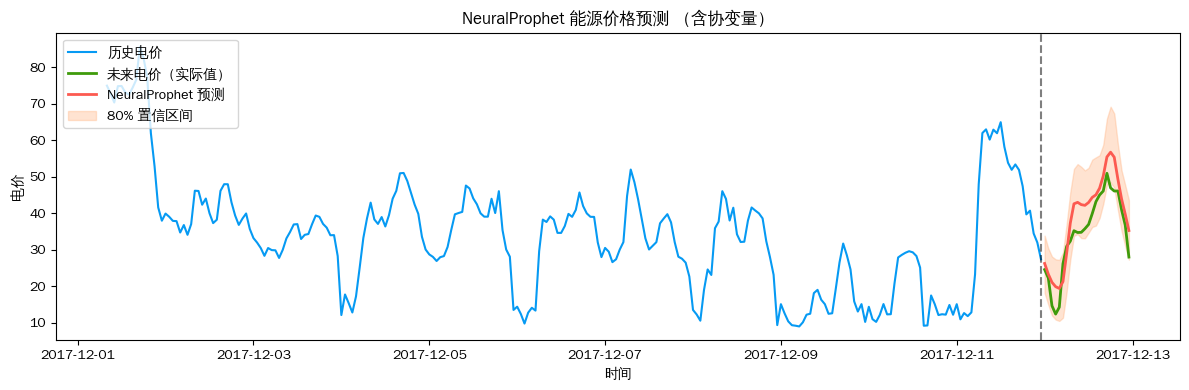

In [6]:
def plot_np_energy(df_context, future_forecast, energy_test_df,
                   timeseries_id, title_suffix=''):
    df_hist = df_context.tail(SHOW_HISTORY)
    df_gt   = (energy_test_df[energy_test_df['id'] == timeseries_id]
               .rename(columns={'timestamp': 'ds'}))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_hist['ds'], df_hist['y'],
            label='历史电价', color='xkcd:azure')
    ax.plot(df_gt['ds'], df_gt['target'],
            label='未来电价（实际值）', color='xkcd:grass green', linewidth=2)
    ax.plot(future_forecast['ds'], future_forecast['yhat1'],
            label='NeuralProphet 预测', color='xkcd:coral', linewidth=2)
    if 'yhat1 10.0%' in future_forecast.columns:
        ax.fill_between(future_forecast['ds'],
                        future_forecast['yhat1 10.0%'], future_forecast['yhat1 90.0%'],
                        alpha=0.35, label='80% 置信区间', color='xkcd:peach')
    ax.axvline(x=df_context['ds'].max(), color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'NeuralProphet 能源价格预测 {title_suffix}')
    ax.set_xlabel('时间')
    ax.set_ylabel('电价')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

plot_np_energy(df_context, future_pred_w, energy_test_df,
               TIMESERIES_ID, title_suffix='（含协变量）')

开始训练（不含协变量）…
Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 267/267 [00:02<00:00, 101.40it/s]


Training: |          | 0/? [01:08<?, ?it/s, v_num=1, train_loss=0.0033, reg_loss=0.000, MAE=7.780, RMSE=11.50, Loss=0.0033, RegLoss=0.000]  
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 222.36it/s]


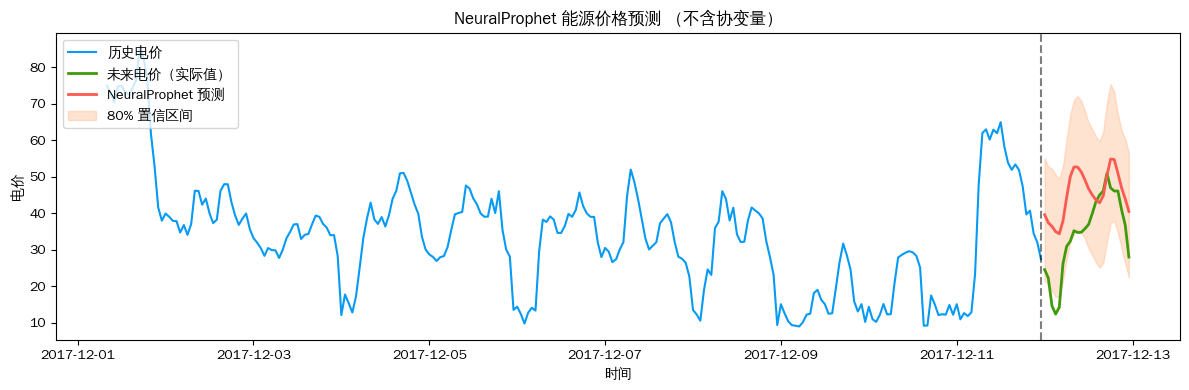

In [7]:
# 对比：不含协变量的基线
m_no_cov = NeuralProphet(
    yearly_seasonality=10, weekly_seasonality=True, daily_seasonality=True,
    seasonality_mode='additive', quantiles=[0.1, 0.9],
    n_forecasts=1, n_lags=0, trainer_config={'accelerator': 'cpu'},
)
print('开始训练（不含协变量）…')
m_no_cov.fit(df_context[['ds', 'y']], freq='H')

future_no_cov    = m_no_cov.make_future_dataframe(df=df_context[['ds', 'y']], periods=PREDICTION_LENGTH)
forecast_no_cov  = m_no_cov.predict(future_no_cov)
future_pred_nc   = forecast_no_cov.tail(PREDICTION_LENGTH)

plot_np_energy(df_context, future_pred_nc, energy_test_df,
               TIMESERIES_ID, title_suffix='（不含协变量）')

In [8]:
# 误差指标对比
gt = (energy_test_df[energy_test_df['id'] == TIMESERIES_ID]
      .sort_values('timestamp')['target'].values)

def calc_metrics(y_true, y_pred, label):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%')

print('─' * 55)
calc_metrics(gt, future_pred_w['yhat1'].values,  'NeuralProphet 含协变量:  ')
calc_metrics(gt, future_pred_nc['yhat1'].values, 'NeuralProphet 不含协变量:')
print('─' * 55)

───────────────────────────────────────────────────────
NeuralProphet 含协变量:    MAE=5.070  RMSE=5.651  MAPE=17.56%
NeuralProphet 不含协变量:  MAE=11.239  RMSE=13.068  MAPE=46.22%
───────────────────────────────────────────────────────
